In [8]:
import openmeteo_requests

import pandas as pd
import requests_cache
from retry_requests import retry

# Setup the Open-Meteo API client with cache and retry on error
cache_session = requests_cache.CachedSession('.cache', expire_after = -1)
retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
openmeteo = openmeteo_requests.Client(session = retry_session)

# 1. API Parameters (Only for features in the image)
url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude": 40.3777,
    "longitude": 49.892,
    "start_date": "2015-01-01",
    "end_date": "2026-04-16",
    "daily": [
        "temperature_2m_mean",          # Index 0 in the image
        "et0_fao_evapotranspiration_sum",# Index 6 in the image
        "sunshine_duration",            # Index 3 in the image
        "shortwave_radiation_sum",      # Index 7 in the image
        "relative_humidity_2m_mean",    # Index 4 in the image
        "surface_pressure_mean",        # Index 9 in the image
        "precipitation_sum",            # Index 1 in the image
        "precipitation_hours",          # Index 2 in the image
        "wind_speed_10m_max",           # Index 8 in the image
        "cloud_cover_mean",             # Index 5 in the image
        "wind_gusts_10m_mean",          # Index 10 in the image
        "soil_moisture_0_to_7cm_mean"   # Our target variable
    ],
}

responses = openmeteo.weather_api(url, params=params)
response = responses[0]
daily = response.Daily()

# 2. Reading data from the API (Following the sequence exactly)
daily_data = {
    "date": pd.date_range(
        start=pd.to_datetime(daily.Time(), unit="s", utc=True),
        end=pd.to_datetime(daily.TimeEnd(), unit="s", utc=True),
        freq=pd.Timedelta(seconds=daily.Interval()),
        inclusive="left"
    ),
    "temperature_2m_mean": daily.Variables(0).ValuesAsNumpy(),
    "et0_fao_evapotranspiration_sum": daily.Variables(1).ValuesAsNumpy(),
    "sunshine_duration": daily.Variables(2).ValuesAsNumpy(),
    "shortwave_radiation_sum": daily.Variables(3).ValuesAsNumpy(),
    "relative_humidity_2m_mean": daily.Variables(4).ValuesAsNumpy(),
    "surface_pressure_mean": daily.Variables(5).ValuesAsNumpy(),
    "precipitation_sum": daily.Variables(6).ValuesAsNumpy(),
    "precipitation_hours": daily.Variables(7).ValuesAsNumpy(),
    "wind_speed_10m_max": daily.Variables(8).ValuesAsNumpy(),
    "cloud_cover_mean": daily.Variables(9).ValuesAsNumpy(),
    "wind_gusts_10m_mean": daily.Variables(10).ValuesAsNumpy(),
    "soil_moisture_0_to_7cm_mean": daily.Variables(11).ValuesAsNumpy()
}

df = pd.DataFrame(data=daily_data)

In [11]:
# 3. Creating Other Calculated Features as shown in the image
# prev_soil_moisture (Yesterday's moisture)
df['prev_soil_moisture'] = df['soil_moisture_0_to_7cm_mean'].shift(1)

# precip_sum_7d (Sum of precipitation over the last 7 days)
df['precip_sum_7d'] = df['precipitation_sum'].rolling(window=7).sum()

# day_of_year (Day of the year)
df['day_of_year'] = df['date'].dt.dayofyear

# The first 7 rows will contain NaN due to 'rolling' and 'shift', so we clean them
df.dropna(inplace=True)

print("\nDataFrame prepared only with the features in the image:\n")
df.head()


DataFrame prepared only with the features in the image:



,date,temperature_2m_mean,et0_fao_evapotranspiration_sum,sunshine_duration,shortwave_radiation_sum,relative_humidity_2m_mean,surface_pressure_mean,precipitation_sum,precipitation_hours,wind_speed_10m_max,cloud_cover_mean,wind_gusts_10m_mean,soil_moisture_0_to_7cm_mean,prev_soil_moisture,precip_sum_7d,day_of_year
18,2015-01-19 00:00:00+00:00,4.753500,1.033541,31512.394531,9.01,83.559387,1028.244751,0.0,0.0,21.986542,29.458334,22.154999,0.173083,0.178333,1.0,19
19,2015-01-20 00:00:00+00:00,6.345167,0.865120,32726.882812,9.47,89.460480,1024.898560,0.0,0.0,25.671307,43.000000,24.750000,0.169542,0.173083,1.0,20
20,2015-01-21 00:00:00+00:00,5.847250,1.055119,33410.996094,9.85,88.103760,1027.502563,0.0,0.0,15.509274,51.458332,13.905002,0.166083,0.169542,1.0,21
21,2015-01-22 00:00:00+00:00,5.701417,0.802787,1402.731934,4.28,86.153473,1027.858276,1.1,7.0,30.602118,92.375000,26.535002,0.169958,0.166083,2.1,22
22,2015-01-23 00:00:00+00:00,4.968083,1.079632,27588.775391,6.32,76.541328,1034.354370,0.0,0.0,23.084955,85.291664,27.690002,0.175958,0.169958,2.1,23


New R2 Score: 0.9726
New MAE: 0.0105


C:\Users\ASUS\AppData\Local\Temp\ipykernel_19772\623739804.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fi_df.head(10), x='Importance', y='Feature', palette='viridis')


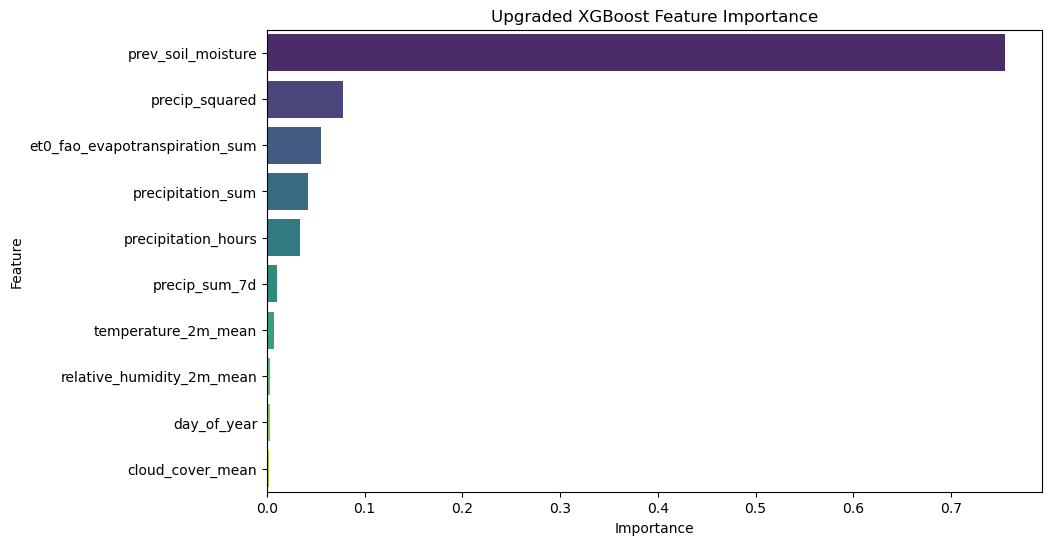

In [13]:
import xgboost as xgb
from sklearn.metrics import r2_score, mean_absolute_error
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Feature Engineering: "Emphasizing" the impact of precipitation
df_upgraded = df.dropna().copy()

# Precipitation squared - makes heavy rainfall more "significant" for the model
df_upgraded['precip_squared'] = df_upgraded['precipitation_sum'] ** 2

# 2. Defining X and y
X_lag = df_upgraded.drop(columns=['date', 'soil_moisture_0_to_7cm_mean'])
y_lag = df_upgraded['soil_moisture_0_to_7cm_mean']

# 3. Time-series split (80/20)
split_idx = int(len(df_upgraded) * 0.8)
X_train_l, X_test_l = X_lag.iloc[:split_idx], X_lag.iloc[split_idx:]
y_train_l, y_test_l = y_lag.iloc[:split_idx], y_lag.iloc[split_idx:]

# 4. Sample Weighting: Increasing the "weight" of rainy days
# Giving 5 times more importance to days with precipitation over 10mm
train_weights = np.where(X_train_l['precipitation_sum'] > 10, 5, 1)

# 5. Tuning the XGBoost Model
xgb_upgraded = xgb.XGBRegressor(
    n_estimators=700, 
    max_depth=5,               
    learning_rate=0.03,        # Slower and more precise learning
    subsample=0.8,
    colsample_bytree=0.9,      # Use 90% of columns (to ensure precipitation isn't missed)
    objective='reg:squarederror',
    random_state=42
)

# Training the model with weights
xgb_upgraded.fit(X_train_l, y_train_l, sample_weight=train_weights)

# 6. Prediction and Metrics
y_pred = xgb_upgraded.predict(X_test_l)

print(f"New R2 Score: {r2_score(y_test_l, y_pred):.4f}")
print(f"New MAE: {mean_absolute_error(y_test_l, y_pred):.4f}")

# 7. Feature Importance Visualization
fi_df = pd.DataFrame({
    'Feature': X_lag.columns, 
    'Importance': xgb_upgraded.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=fi_df.head(10), x='Importance', y='Feature', palette='viridis')
plt.title('Upgraded XGBoost Feature Importance')
plt.show()

In [14]:
# 1. Get all features the model learned and their medians
all_features_upgraded = X_train_l.columns.tolist()
median_vals_upgraded = X_train_l.median()

def stress_test_upgraded(prev_moisture, temp, precip, et0):
    """
    Stress Test for the Upgraded XGBoost model.
    """
    test_dict = {}
    
    for feature in all_features_upgraded:
        # Adjust specific variables
        if feature == 'prev_soil_moisture' or feature == 'soil_moisture_0_to_7cm_mean_lag1':
            test_dict[feature] = prev_moisture
        elif feature == 'temperature_2m_mean':
            test_dict[feature] = temp
        elif feature == 'precipitation_sum':
            test_dict[feature] = precip
        elif feature == 'precip_squared': # Important column we newly created!
            test_dict[feature] = precip ** 2
        elif feature == 'et0_fao_evapotranspiration_sum':
            test_dict[feature] = et0
        elif feature == 'day_of_year':
            test_dict[feature] = 110 # End of April
        elif feature == 'precip_sum_7d':
            test_dict[feature] = precip 
        else:
            # Fill other columns with medians
            test_dict[feature] = median_vals_upgraded[feature]
            
    # Convert to DataFrame format (Column order must be preserved)
    test_df = pd.DataFrame([test_dict])[all_features_upgraded]
    
    # Prediction with the new model
    prediction = xgb_upgraded.predict(test_df)[0]
    ferq = prediction - prev_moisture
    
    print(f"--- UPGRADED XGBOOST TEST ---")
    print(f"Base Moisture: {prev_moisture:.4f}")
    print(f"Weather Conditions: {precip} mm Rain | {temp}°C Temp")
    print(f"New Model Prediction: {prediction:.4f}")
    print(f"Moisture Change: {ferq:+.4f}") # Shows increase or decrease
    print("-" * 30)

# --- RUN SCENARIOS ---

print("SCENARIO 1: Extreme Rain (60 mm)")
# prev_moisture=0.20, temp=12, precip=60.0, et0=0.5
stress_test_upgraded(0.20, 12, 60.0, 0.5) 

print("\nSCENARIO 2: Extreme Heat and Drought (38°C)")
# prev_moisture=0.20, temp=38, precip=0.0, et0=8.0
stress_test_upgraded(0.20, 38, 0.0, 8.0)

SCENARIO 1: Extreme Rain (60 mm)
--- UPGRADED XGBOOST TEST ---
Base Moisture: 0.2000
Weather Conditions: 60.0 mm Rain | 12°C Temp
New Model Prediction: 0.3140
Moisture Change: +0.1140
------------------------------

SCENARIO 2: Extreme Heat and Drought (38°C)
--- UPGRADED XGBOOST TEST ---
Base Moisture: 0.2000
Weather Conditions: 0.0 mm Rain | 38°C Temp
New Model Prediction: 0.1781
Moisture Change: -0.0219
------------------------------


In [15]:
# 8. Evaluating R2 Score for both Training and Testing sets
from sklearn.metrics import r2_score

# Getting predictions for both sets
y_train_pred = xgb_upgraded.predict(X_train_l)
y_test_pred = xgb_upgraded.predict(X_test_l)

# Calculating R2 scores
r2_train = r2_score(y_train_l, y_train_pred)
r2_test = r2_score(y_test_l, y_test_pred)

print(f"Training R2 Score: {r2_train:.4f}")
print(f"Testing R2 Score: {r2_test:.4f}")

# Optional: Checking for Overfitting
if r2_train > r2_test + 0.1:
    print("Warning: The model might be overfitting (Train R2 is significantly higher than Test R2).")
else:
    print("The model generalization looks consistent.")

Training R2 Score: 0.9984
Testing R2 Score: 0.9726
The model generalization looks consistent.


In [16]:
import joblib

# Saving the model with the name 'BAKU_0_7_xgb.pkl'
joblib.dump(xgb_upgraded, 'BAKU_0_7_xgb.pkl')

print("Model saved successfully!")

Model saved successfully!


14-Day Forecast MAE : 0.0221
14-Day Forecast R²  : 0.6638

1-günlük Test R²    : 0.9726
14-günlük Forecast R²: 0.6638
Düşüş               : 0.3088


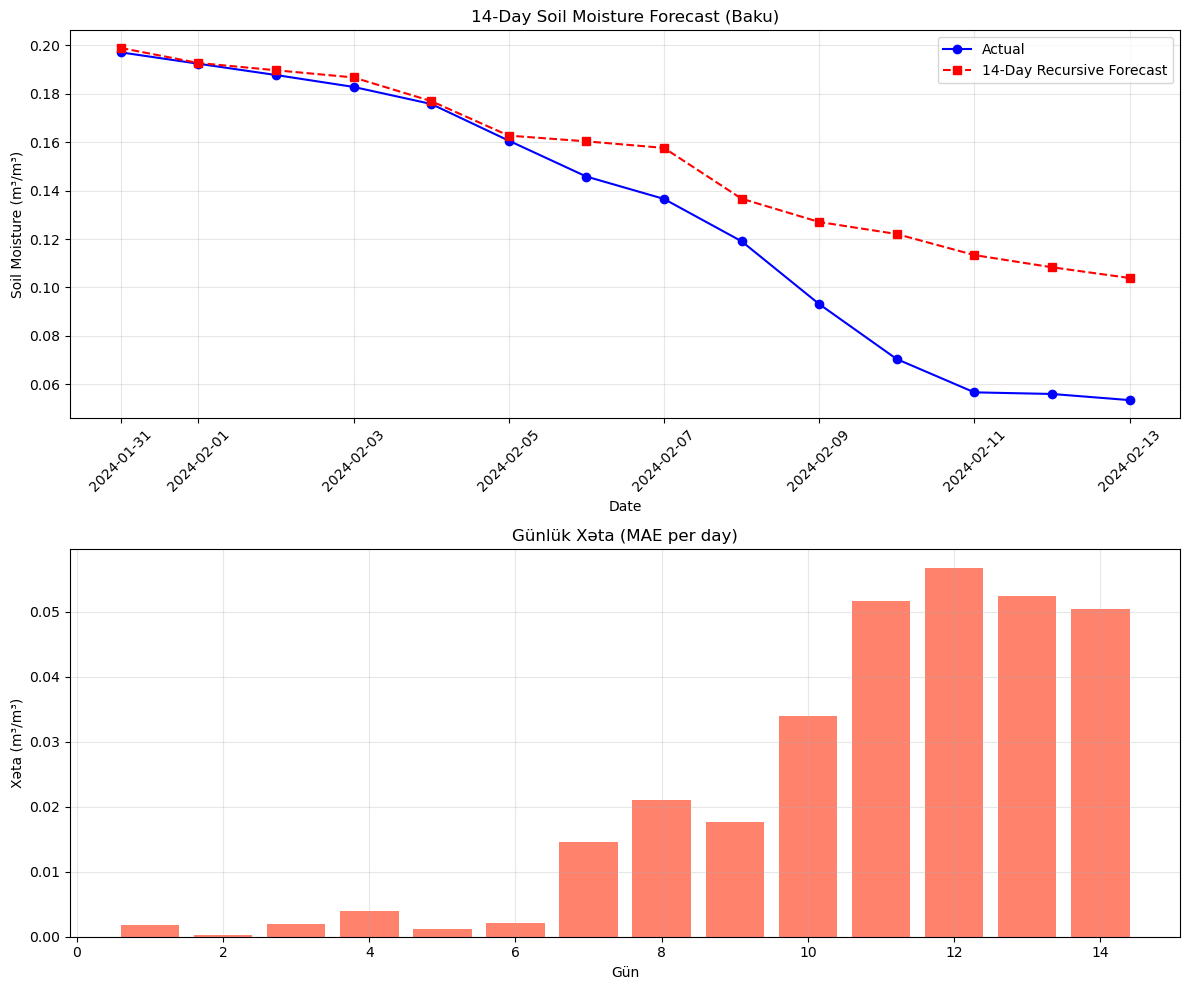

In [21]:
from collections import deque

# ── Parametrlər ────────────────────────────────────────────────────
forecast_steps = 14
start_idx      = 15

# ── Başlanğıc nöqtəsi ──────────────────────────────────────────────
current_features      = X_test_l.iloc[start_idx:start_idx + 1].copy()
iterative_predictions = []
actual_values         = y_test_l.iloc[start_idx:start_idx + forecast_steps].values
test_dates            = df_upgraded['date'].iloc[split_idx:].reset_index(drop=True)

# precip_sum_7d üçün sürüşən pəncərə
has_7d = 'precip_sum_7d' in X_test_l.columns
if has_7d:
    init_precip  = X_test_l.iloc[start_idx]['precip_sum_7d'] / 7
    precip_queue = deque([init_precip] * 7, maxlen=7)

# ── Recursive Forecast ─────────────────────────────────────────────
for i in range(forecast_steps):
    pred = xgb_upgraded.predict(current_features)[0]
    iterative_predictions.append(pred)

    if i < forecast_steps - 1:
        next_features = X_test_l.iloc[start_idx + i + 1:start_idx + i + 2].copy()

        # prev_soil_moisture → öz proqnozumuzla əvəz et
        if 'prev_soil_moisture' in next_features.columns:
            next_features['prev_soil_moisture'] = pred

        # precip_sum_7d → dinamik yenilə
        if has_7d:
            precip_queue.append(X_test_l.iloc[start_idx + i]['precipitation_sum'])
            next_features['precip_sum_7d'] = sum(precip_queue)

        # precip_squared → yenilə
        if 'precip_squared' in next_features.columns:
            next_features['precip_squared'] = next_features['precipitation_sum'] ** 2

        current_features = next_features

# ── Metrikalar ─────────────────────────────────────────────────────
mae_14 = mean_absolute_error(actual_values, iterative_predictions)
r2_14  = r2_score(actual_values, iterative_predictions)

print(f"14-Day Forecast MAE : {mae_14:.4f}")
print(f"14-Day Forecast R²  : {r2_14:.4f}")

# 1 günlük test R² ilə müqayisə
r2_1day = r2_score(y_test_l, xgb_upgraded.predict(X_test_l))
print(f"\n1-günlük Test R²    : {r2_1day:.4f}")
print(f"14-günlük Forecast R²: {r2_14:.4f}")
print(f"Düşüş               : {r2_1day - r2_14:.4f}")

# ── Vizuallaşdırma ─────────────────────────────────────────────────
forecast_dates = test_dates.iloc[start_idx:start_idx + forecast_steps]

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Qrafik 1 — Actual vs Forecast
axes[0].plot(forecast_dates, actual_values,
             marker='o', label='Actual', color='blue')
axes[0].plot(forecast_dates, iterative_predictions,
             marker='s', label='14-Day Recursive Forecast',
             color='red', linestyle='--')
axes[0].set_title('14-Day Soil Moisture Forecast (Baku)')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Soil Moisture (m³/m³)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

# Qrafik 2 — Günlük xəta
daily_errors = np.abs(np.array(actual_values) - np.array(iterative_predictions))
axes[1].bar(range(1, forecast_steps + 1), daily_errors, color='tomato', alpha=0.8)
axes[1].set_title('Günlük Xəta (MAE per day)')
axes[1].set_xlabel('Gün')
axes[1].set_ylabel('Xəta (m³/m³)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [23]:
import pandas as pd
import numpy as np

# 14 günlük saxta hava proqnozu yaradaq test üçün
forecast_df = pd.DataFrame({
    'date': pd.date_range('2026-04-29', periods=14, freq='D'),
    'temperature_2m_mean': np.random.uniform(10, 25, 14),
    'et0_fao_evapotranspiration_sum': np.random.uniform(0.5, 5.0, 14),
    'shortwave_radiation_sum': np.random.uniform(5, 25, 14),
    'precipitation_sum': np.random.uniform(0, 20, 14),
    'relative_humidity_2m_mean': np.random.uniform(40, 90, 14),
    'surface_pressure_mean': np.random.uniform(1005, 1025, 14),
    'sunshine_duration': np.random.uniform(20000, 40000, 14),
    'precipitation_hours': np.random.uniform(0, 10, 14),
    'wind_gusts_10m_mean': np.random.uniform(10, 40, 14),
    'cloud_cover_mean': np.random.uniform(0, 100, 14),
    'wind_speed_10m_max': np.random.uniform(5, 30, 14),
    'day_of_year': pd.date_range('2026-04-29', periods=14, freq='D').dayofyear
})


In [24]:
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np
import pandas as pd

# --- Başlanğıc dəyəri (son real ölçülmüş nəm) ---
last_real_moisture = df_upgraded['soil_moisture_0_to_7cm_mean'].iloc[-1]

# --- 14 günlük hava proqnozu DataFrame (bunu artıq pipeline-dan və ya forecast API-dən oxuya bilərsən)
# forecast_df aşağıdakı sütunlara sahib olmalıdır:
# ['temperature_2m_mean', 'et0_fao_evapotranspiration_sum', 'shortwave_radiation_sum',
#  'precipitation_sum', 'relative_humidity_2m_mean', 'surface_pressure_mean',
#  'sunshine_duration', 'precipitation_hours', 'wind_gusts_10m_mean',
#  'cloud_cover_mean', 'wind_speed_10m_max', 'day_of_year']

forecast_steps = 14

current_moisture = last_real_moisture
predictions = []

for i in range(forecast_steps):
    row = forecast_df.iloc[i].copy()

    row['prev_soil_moisture'] = current_moisture
    row['precip_squared'] = row['precipitation_sum'] ** 2
    row['precip_sum_7d'] = forecast_df['precipitation_sum'].iloc[max(0, i-6):i+1].sum()

    # DataFrame modelin feature ardıcıllığı ilə düzülür
    input_df = pd.DataFrame([row])[X_lag.columns]

    pred = xgb_upgraded.predict(input_df)[0]
    predictions.append(pred)

    current_moisture = pred  # növbəti gün üçün yenilənmiş nəm

# 14 günlük forecast nəticələrini əlavə edirik
forecast_df['predicted_moisture'] = predictions

# Əgər real observer data varsa, müqayisə üçün metriki hesablaya bilərsən:
if 'soil_moisture_0_to_7cm_mean' in forecast_df.columns:
    r2 = r2_score(forecast_df['soil_moisture_0_to_7cm_mean'], forecast_df['predicted_moisture'])
    mae = mean_absolute_error(forecast_df['soil_moisture_0_to_7cm_mean'], forecast_df['predicted_moisture'])
    print(f"R² (14-day recursive): {r2:.4f}")
    print(f"MAE (14-day recursive): {mae:.4f}")
else:
    print("⚠️ Real moisture dəyərləri forecast_df-də tapılmadı; yalnız proqnoz göstərilir.")

print("\n📊 14 Günlük Torpaq Nəmliyinin Proqnozu:")
print(forecast_df[['date', 'predicted_moisture']])


⚠️ Real moisture dəyərləri forecast_df-də tapılmadı; yalnız proqnoz göstərilir.

📊 14 Günlük Torpaq Nəmliyinin Proqnozu:
         date  predicted_moisture
0  2026-04-29            0.256142
1  2026-04-30            0.270370
2  2026-05-01            0.342988
3  2026-05-02            0.344452
4  2026-05-03            0.343068
5  2026-05-04            0.351609
6  2026-05-05            0.343149
7  2026-05-06            0.369004
8  2026-05-07            0.357740
9  2026-05-08            0.354202
10 2026-05-09            0.330607
11 2026-05-10            0.314193
12 2026-05-11            0.348921
13 2026-05-12            0.345094


In [25]:
from sklearn.metrics import r2_score, mean_absolute_error
import pandas as pd
import numpy as np

# 14 günlük rekursiv test
steps = 14
current_moisture = y_test_l.iloc[0]       # ilk real dəyər (start state)
predictions, actuals = [], []

for i in range(steps):
    # i-ci günün inputunu əldə et və 'prev_soil_moisture' kimi son nəmliyi əlavə et
    row = X_test_l.iloc[i].copy()
    row["prev_soil_moisture"] = current_moisture
    row["precip_squared"] = row["precipitation_sum"] ** 2

    input_df = pd.DataFrame([row])[X_train_l.columns]
    pred = xgb_upgraded.predict(input_df)[0]
    predictions.append(pred)
    actuals.append(y_test_l.iloc[i])

    current_moisture = pred  # növbəti gün üçün keçid

# 14 günlük real və proqnoz fərqlərini hesabla
r2 = r2_score(actuals, predictions)
mae = mean_absolute_error(actuals, predictions)

print(f"🔁 14 Günlük Rekursiv Forecast Performansı:")
print(f"R² Score: {r2:.4f}")
print(f"MAE: {mae:.4f}")

results_df = pd.DataFrame({
    "Day": range(1, steps + 1),
    "Actual": actuals,
    "Predicted": predictions
})

print("\n📊 Nəticələr:")
print(results_df)


🔁 14 Günlük Rekursiv Forecast Performansı:
R² Score: 0.5417
MAE: 0.0079

📊 Nəticələr:
    Day    Actual  Predicted
0     1  0.180125   0.176932
1     2  0.175625   0.172909
2     3  0.168125   0.172900
3     4  0.165625   0.173550
4     5  0.159125   0.168259
5     6  0.156750   0.164167
6     7  0.159833   0.170958
7     8  0.172250   0.179585
8     9  0.178250   0.187343
9    10  0.177500   0.181369
10   11  0.173125   0.173863
11   12  0.179208   0.185079
12   13  0.203708   0.183011
13   14  0.204917   0.188315


C:\Users\ASUS\anaconda3\envs\ironhack\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\ASUS\anaconda3\envs\ironhack\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\ASUS\anaconda3\envs\ironhack\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\ASUS\anaconda3\envs\ironhack\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Users\ASUS\anaconda3\envs\ironhack\Lib\site-packag

🔮 14 Günlük SARIMAX Forecast Nəticələri
R²:   -1.6278
MAE:  0.0565
RMSE: 0.0703

📊 14 Günlük Forecast Cədvəli:
                        date    actual  predicted
0  2026-04-03 00:00:00+00:00  0.307792   0.296796
1  2026-04-04 00:00:00+00:00  0.370083   0.307507
2  2026-04-05 00:00:00+00:00  0.383542   0.315381
3  2026-04-06 00:00:00+00:00  0.378917   0.278782
4  2026-04-07 00:00:00+00:00  0.347292   0.221163
5  2026-04-08 00:00:00+00:00  0.318125   0.210960
6  2026-04-09 00:00:00+00:00  0.307458   0.201863
7  2026-04-10 00:00:00+00:00  0.293625   0.205344
8  2026-04-11 00:00:00+00:00  0.274208   0.272452
9  2026-04-12 00:00:00+00:00  0.263292   0.311508
10 2026-04-13 00:00:00+00:00  0.258083   0.297053
11 2026-04-14 00:00:00+00:00  0.285750   0.276822
12 2026-04-15 00:00:00+00:00  0.272875   0.260447
13 2026-04-16 00:00:00+00:00  0.257417   0.245518


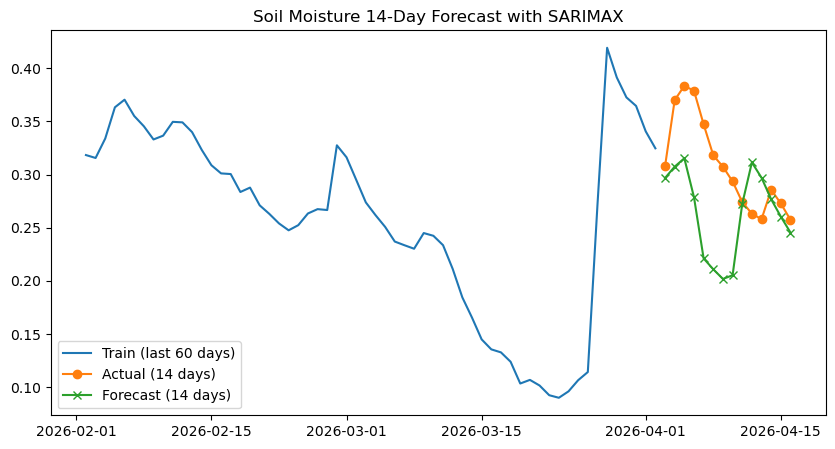

In [26]:
import pandas as pd
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# -----------------------------------
# 1️⃣  Data Hazırlanması
# -----------------------------------
# df: 10 illik tarixi datadir
# 'date' datetime, 'soil_moisture_0_to_7cm_mean' target

df = df.dropna(subset=['soil_moisture_0_to_7cm_mean']).copy()
df = df.sort_values('date')

df.set_index('date', inplace=True)
target = df['soil_moisture_0_to_7cm_mean']

# (Əgər hava dəyişənlərini “exog” kimi istifadə etmək istəyirsənsə)
exog_vars = ['temperature_2m_mean', 'precipitation_sum', 'relative_humidity_2m_mean']
exog = df[exog_vars]

# -----------------------------------
# 2️⃣  Train-test bölünməsi (son 14 gün test)
# -----------------------------------
train_size = len(df) - 14
y_train, y_test = target.iloc[:train_size], target.iloc[train_size:]
exog_train, exog_test = exog.iloc[:train_size], exog.iloc[train_size:]

# -----------------------------------
# 3️⃣  SARIMAX Modeli
# -----------------------------------
model = SARIMAX(
    y_train,
    order=(2, 0, 2),              # p, d, q parametrləri (sınaqla optimallaşdırmaq olar)
    seasonal_order=(1, 1, 1, 7),  # həftəlik seasonality
    exog=exog_train               # istəsən None da verə bilərsən
)
model_fit = model.fit(disp=False)

# -----------------------------------
# 4️⃣  14 günlük proqnoz
# -----------------------------------
forecast = model_fit.forecast(steps=14, exog=exog_test)

# -----------------------------------
# 5️⃣  Nəticə və metriklər
# -----------------------------------
y_pred = forecast.values
y_true = y_test.values

r2 = r2_score(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

print("🔮 14 Günlük SARIMAX Forecast Nəticələri")
print(f"R²:   {r2:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

results_df = pd.DataFrame({
    "date": y_test.index,
    "actual": y_true,
    "predicted": y_pred
})
print("\n📊 14 Günlük Forecast Cədvəli:")
print(results_df)

# -----------------------------------
# 6️⃣  Vizual plot (istəyə görə)
# -----------------------------------
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(y_train.index[-60:], y_train.values[-60:], label='Train (last 60 days)')
plt.plot(y_test.index, y_true, label='Actual (14 days)', marker='o')
plt.plot(y_test.index, y_pred, label='Forecast (14 days)', marker='x')
plt.legend()
plt.title("Soil Moisture 14-Day Forecast with SARIMAX")
plt.show()
